# Modelo Binario: ¿Supera el Estudiante el Nivel Más Bajo de Inglés?
**Pregunta de negocio:** ¿Qué estudiantes tienen mayor probabilidad de superar el nivel más bajo de desempeño en inglés en Saber 11?

**Variable objetivo:** `SUPERA_NIVEL_BAJO_INGLES`  
- `0` → nivel `A-` (no supera)
- `1` → niveles `A1`, `A2`, `B1`, `B+` (supera)

**Usuario final:** Secretaría de Educación de Santander  
**Experimento MLflow:** `clasificacion_binaria_supera_nivel_bajo_ingles`

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.keras
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('MLflow version:', mlflow.__version__)

TensorFlow version: 2.21.0
MLflow version: 3.12.0


## 2. Carga y limpieza de datos

In [2]:
df = pd.read_csv('data\Resultados_únicos_Saber_11_Santander.csv')
print('Shape original:', df.shape)

df = df.drop_duplicates(keep='first')
print('Shape sin duplicados:', df.shape)

niveles_validos = ['A-', 'A1', 'A2', 'B1', 'B+']
df = df.dropna(subset=['DESEMP_INGLES'])
df = df[df['DESEMP_INGLES'].isin(niveles_validos)].copy()
print('Shape con niveles válidos:', df.shape)
df.head()

Shape original: (346512, 51)
Shape sin duplicados: (272983, 51)
Shape con niveles válidos: (272967, 51)


,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,...,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20194,TI,SB11201940226736,URBANO,N,A,TÉCNICO/ACADÉMICO,168001002421,168001002421,68,...,Si,Si,Si,A2,61.0,64.0,49.0,59.0,63.0,295.0
2,20172,TI,SB11201720104447,URBANO,N,A,TÉCNICO/ACADÉMICO,168307001002,168307001002,68,...,No,No,Si,A-,47.0,59.0,64.0,59.0,68.0,307.0
3,20122,TI,SB11201220024292,URBANO,N,A,ACADÉMICO,368655001261,368655001261,68,...,No,No,Si,A1,46.0,45.0,NaN,NaN,NaN,NaN
4,20122,TI,SB11201220007144,URBANO,N,A,ACADÉMICO,368001002837,368001002837,68,...,NaN,Si,Si,A1,51.0,61.0,NaN,NaN,NaN,NaN
5,20172,TI,SB11201720187961,URBANO,N,A,TÉCNICO/ACADÉMICO,168547000011,168547000011,68,...,No,Si,Si,A-,44.0,45.0,45.0,50.0,46.0,232.0


## 3. Creación de variable objetivo binaria

Distribución de SUPERA_NIVEL_BAJO_INGLES:
                          Conteo  Porcentaje (%)
0 – No supera (A-)        127452           46.69
1 – Supera (A1/A2/B1/B+)  145515           53.31


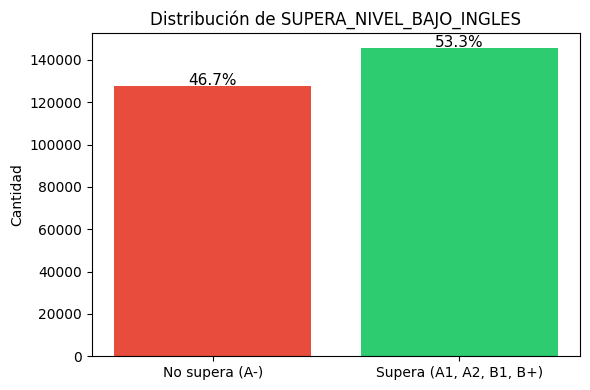

In [3]:
df['SUPERA_NIVEL_BAJO_INGLES'] = df['DESEMP_INGLES'].apply(
    lambda x: 0 if x == 'A-' else 1
)

conteos     = df['SUPERA_NIVEL_BAJO_INGLES'].value_counts().sort_index()
porcentajes = df['SUPERA_NIVEL_BAJO_INGLES'].value_counts(normalize=True).sort_index() * 100
dist = pd.DataFrame({'Conteo': conteos, 'Porcentaje (%)': porcentajes.round(2)})
dist.index = ['0 – No supera (A-)', '1 – Supera (A1/A2/B1/B+)']
print('Distribución de SUPERA_NIVEL_BAJO_INGLES:')
print(dist)

plt.figure(figsize=(6, 4))
bars = plt.bar(['No supera (A-)', 'Supera (A1, A2, B1, B+)'],
               conteos.values, color=['#e74c3c', '#2ecc71'])
for bar, pct in zip(bars, porcentajes.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 500, f'{pct:.1f}%', ha='center', fontsize=11)
plt.title('Distribución de SUPERA_NIVEL_BAJO_INGLES')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.savefig('eda_binario_ingles.png', dpi=150)
plt.show()

## 4. Selección de variables e ingeniería de características

In [4]:
# EDAD derivada de PERIODO y ESTU_FECHANACIMIENTO
df['ANIO_EXAMEN'] = df['PERIODO'].astype(str).str[:4].astype(int)
df['ANIO_NACIMIENTO'] = pd.to_datetime(
    df['ESTU_FECHANACIMIENTO'], errors='coerce'
).dt.year
df['EDAD'] = (df['ANIO_EXAMEN'] - df['ANIO_NACIMIENTO']).clip(14, 25)

target = 'SUPERA_NIVEL_BAJO_INGLES'

candidatas = [
    'PERIODO', 'EDAD',
    'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_CALENDARIO',
    'COLE_CARACTER', 'COLE_GENERO', 'COLE_JORNADA', 'COLE_MCPIO_UBICACION',
    'COLE_NATURALEZA', 'COLE_SEDE_PRINCIPAL',
    'ESTU_GENERO', 'ESTU_PRIVADO_LIBERTAD', 'ESTU_HORASSEMANATRABAJA',
    'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
    'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA',
]

features = [f for f in candidatas if f in df.columns]
print(f'Features disponibles ({len(features)}):')
for f in features:
    print(f'  {f}')

X = df[features].copy()
y = df[target].copy()
print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')

Features disponibles (22):
  PERIODO
  EDAD
  COLE_AREA_UBICACION
  COLE_BILINGUE
  COLE_CALENDARIO
  COLE_CARACTER
  COLE_GENERO
  COLE_JORNADA
  COLE_MCPIO_UBICACION
  COLE_NATURALEZA
  COLE_SEDE_PRINCIPAL
  ESTU_GENERO
  ESTU_PRIVADO_LIBERTAD
  FAMI_CUARTOSHOGAR
  FAMI_EDUCACIONMADRE
  FAMI_EDUCACIONPADRE
  FAMI_ESTRATOVIVIENDA
  FAMI_PERSONASHOGAR
  FAMI_TIENEAUTOMOVIL
  FAMI_TIENECOMPUTADOR
  FAMI_TIENEINTERNET
  FAMI_TIENELAVADORA

Shape X: (272967, 22)
Shape y: (272967,)


## 5. Preprocesamiento

In [5]:
categorical_features = [f for f in features if X[f].dtype == 'object']
numeric_features     = [f for f in features if X[f].dtype in ['int64', 'float64']]

print('Categóricas:', categorical_features)
print('Numéricas:  ', numeric_features)

# Categóricas: imputar con "Desconocido" + OHE
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numéricas: imputar con mediana + escalado
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features),
    ('num', numeric_transformer,     numeric_features)
])

Categóricas: ['COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_CALENDARIO', 'COLE_CARACTER', 'COLE_GENERO', 'COLE_JORNADA', 'COLE_MCPIO_UBICACION', 'COLE_NATURALEZA', 'COLE_SEDE_PRINCIPAL', 'ESTU_GENERO', 'ESTU_PRIVADO_LIBERTAD', 'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA']
Numéricas:   ['PERIODO', 'EDAD']


## 6. División train/test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', X_train.shape)
print('Test: ', X_test.shape)

u_tr, c_tr = np.unique(y_train, return_counts=True)
u_te, c_te = np.unique(y_test,  return_counts=True)
print('Distribución train:', dict(zip(u_tr.tolist(), c_tr.tolist())))
print('Distribución test: ', dict(zip(u_te.tolist(), c_te.tolist())))

Train: (218373, 22)
Test:  (54594, 22)
Distribución train: {0: 101961, 1: 116412}
Distribución test:  {0: 25491, 1: 29103}


In [7]:
os.makedirs('models', exist_ok=True)

X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_test_proc  = preprocessor.transform(X_test)

joblib.dump(preprocessor, 'models/preprocessor_binario_ingles.pkl')
print('X_train procesado:', X_train_proc.shape)
print('X_test procesado: ', X_test_proc.shape)
print('Preprocessor guardado: models/preprocessor_binario_ingles.pkl')

X_train procesado: (218373, 230)
X_test procesado:  (54594, 230)
Preprocessor guardado: models/preprocessor_binario_ingles.pkl


## 7. Modelamiento con Red Neuronal Binaria

In [8]:
n_input = X_train_proc.shape[1]

def build_binary_model(layer_sizes, dropout_rate, learning_rate, activation='relu'):
    """Red neuronal binaria: salida 1 neurona sigmoid, pérdida binary_crossentropy."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(n_input,)))
    for size in layer_sizes:
        model.add(layers.Dense(size, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('clasificacion_binaria_supera_nivel_bajo_ingles')

experimentos_nn = [
    {'layer_sizes': [128, 64],           'dropout': 0.2, 'lr': 0.001,  'activation': 'relu'},
    {'layer_sizes': [128, 64],           'dropout': 0.2, 'lr': 0.001,  'activation': 'elu'},
    {'layer_sizes': [256, 128, 64],      'dropout': 0.3, 'lr': 0.001,  'activation': 'relu'},
    {'layer_sizes': [256, 128, 64],      'dropout': 0.3, 'lr': 0.001,  'activation': 'elu'},
    {'layer_sizes': [256, 128, 64],      'dropout': 0.3, 'lr': 0.001,  'activation': 'tanh'},
    {'layer_sizes': [512, 256, 128],     'dropout': 0.3, 'lr': 0.001,  'activation': 'relu'},
    {'layer_sizes': [512, 256, 128],     'dropout': 0.3, 'lr': 0.001,  'activation': 'elu'},
    {'layer_sizes': [512, 256, 128, 64], 'dropout': 0.3, 'lr': 0.001,  'activation': 'relu'},
    {'layer_sizes': [512, 256, 128, 64], 'dropout': 0.2, 'lr': 0.001,  'activation': 'elu'},
    {'layer_sizes': [512, 256, 128, 64], 'dropout': 0.3, 'lr': 0.0005, 'activation': 'relu'},
    {'layer_sizes': [512, 256, 128, 64], 'dropout': 0.2, 'lr': 0.0005, 'activation': 'elu'},
]

cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(zip(np.unique(y_train).tolist(), cw_arr.tolist()))
print('Class weights:', class_weights)

resultados_nn = []
best_nn_f1    = 0
best_nn_model = None
best_nn_exp   = None

for exp in experimentos_nn:
    act       = exp['activation']
    sizes_str = '_'.join(str(s) for s in exp['layer_sizes'])
    dr        = exp['dropout']
    lr        = exp['lr']
    run_name  = f"NN_bin_layers{sizes_str}_{act}_dr{dr}_lr{lr}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param('model_type',  'RedNeuronal_Binaria')
        mlflow.log_param('layer_sizes', str(exp['layer_sizes']))
        mlflow.log_param('dropout',     dr)
        mlflow.log_param('lr',          lr)
        mlflow.log_param('activation',  act)
        mlflow.log_param('n_layers',    len(exp['layer_sizes']))

        model = build_binary_model(exp['layer_sizes'], dr, lr, act)

        history = model.fit(
            X_train_proc, y_train,
            validation_split=0.2,
            epochs=100,
            batch_size=256,
            verbose=0,
            class_weight=class_weights,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=15, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(
                    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
            ]
        )

        y_prob = model.predict(X_test_proc, verbose=0).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_prob)

        mlflow.log_metric('accuracy',       acc)
        mlflow.log_metric('precision',      prec)
        mlflow.log_metric('recall',         rec)
        mlflow.log_metric('f1_score',       f1)
        mlflow.log_metric('roc_auc',        auc)
        mlflow.log_metric('val_loss_final', min(history.history['val_loss']))

        cm = confusion_matrix(y_test, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    xticklabels=['No supera', 'Supera'],
                    yticklabels=['No supera', 'Supera'])
        ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
        ax.set_title(f'CM - {run_name}')
        plt.tight_layout()
        mlflow.log_figure(fig, 'confusion_matrix.png')
        plt.close(fig)

        report = classification_report(
            y_test, y_pred, target_names=['No supera (A-)', 'Supera'])
        mlflow.log_text(report, 'classification_report.txt')
        mlflow.keras.log_model(model, 'model')

        resultados_nn.append({
            'modelo': 'RedNeuronal', 'run_name': run_name,
            'accuracy': round(acc, 4), 'precision': round(prec, 4),
            'recall': round(rec, 4), 'f1_score': round(f1, 4), 'roc_auc': round(auc, 4)
        })

        print(f"{run_name} -> Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

        if f1 > best_nn_f1:
            best_nn_f1    = f1
            best_nn_model = model
            best_nn_exp   = exp

print()
print(f"Mejor NN -> F1={best_nn_f1:.3f} | Config: {best_nn_exp}")

2026/05/24 21:48:26 INFO mlflow.tracking.fluent: Experiment with name 'clasificacion_binaria_supera_nivel_bajo_ingles' does not exist. Creating a new experiment.


Class weights: {0: 1.0708653308618001, 1: 0.9379316565302546}


2026/05/24 21:48:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 21:48:58 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


NN_bin_layers128_64_relu_dr0.2_lr0.001 -> Acc=0.691 | F1=0.703 | AUC=0.763


2026/05/24 21:50:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 21:50:08 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


...

NN_bin_layers512_256_128_64_elu_dr0.2_lr0.001 -> Acc=0.691 | F1=0.700 | AUC=0.764


2026/05/24 22:01:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 22:01:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


NN_bin_layers512_256_128_64_relu_dr0.3_lr0.0005 -> Acc=0.690 | F1=0.702 | AUC=0.762


2026/05/24 22:03:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 22:03:27 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


NN_bin_layers512_256_128_64_elu_dr0.2_lr0.0005 -> Acc=0.692 | F1=0.706 | AUC=0.764

Mejor NN -> F1=0.706 | Config: {'layer_sizes': [512, 256, 128, 64], 'dropout': 0.2, 'lr': 0.0005, 'activation': 'elu'}


## 8. Modelo de referencia: XGBoost binario

In [10]:
from xgboost import XGBClassifier

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('clasificacion_binaria_supera_nivel_bajo_ingles')

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_configs = [
    {'n_estimators': 200, 'max_depth': 4, 'lr': 0.1,  'subsample': 0.8},
    {'n_estimators': 300, 'max_depth': 6, 'lr': 0.1,  'subsample': 0.8},
    {'n_estimators': 300, 'max_depth': 6, 'lr': 0.05, 'subsample': 0.8},
    {'n_estimators': 400, 'max_depth': 8, 'lr': 0.05, 'subsample': 0.7},
]

resultados_xgb = []
best_xgb_f1    = 0
best_xgb_model = None
best_xgb_cfg   = None

for cfg in xgb_configs:
    d, n, lr = cfg['max_depth'], cfg['n_estimators'], cfg['lr']
    run_name = f"XGB_bin_n{n}_d{d}_lr{lr}"

    with mlflow.start_run(run_name=run_name):
        mlflow.log_param('model_type',   'XGBoost_Binario')
        mlflow.log_param('n_estimators', n)
        mlflow.log_param('max_depth',    d)
        mlflow.log_param('lr',           lr)
        mlflow.log_param('subsample',    cfg['subsample'])

        xgb = XGBClassifier(
            n_estimators=n, max_depth=d, learning_rate=lr,
            subsample=cfg['subsample'], colsample_bytree=0.8,
            eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0
        )
        xgb.fit(X_train_proc, y_train, sample_weight=sample_weights)

        y_prob_xgb = xgb.predict_proba(X_test_proc)[:, 1]
        y_pred_xgb = xgb.predict(X_test_proc)

        acc  = accuracy_score(y_test, y_pred_xgb)
        prec = precision_score(y_test, y_pred_xgb, zero_division=0)
        rec  = recall_score(y_test, y_pred_xgb, zero_division=0)
        f1   = f1_score(y_test, y_pred_xgb, zero_division=0)
        auc  = roc_auc_score(y_test, y_prob_xgb)

        mlflow.log_metric('accuracy',  acc)
        mlflow.log_metric('precision', prec)
        mlflow.log_metric('recall',    rec)
        mlflow.log_metric('f1_score',  f1)
        mlflow.log_metric('roc_auc',   auc)

        cm = confusion_matrix(y_test, y_pred_xgb)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                    xticklabels=['No supera', 'Supera'],
                    yticklabels=['No supera', 'Supera'])
        ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
        ax.set_title(f'CM - {run_name}')
        plt.tight_layout()
        mlflow.log_figure(fig, 'confusion_matrix.png')
        plt.close(fig)

        report = classification_report(
            y_test, y_pred_xgb, target_names=['No supera (A-)', 'Supera'])
        mlflow.log_text(report, 'classification_report.txt')

        resultados_xgb.append({
            'modelo': 'XGBoost', 'run_name': run_name,
            'accuracy': round(acc, 4), 'precision': round(prec, 4),
            'recall': round(rec, 4), 'f1_score': round(f1, 4), 'roc_auc': round(auc, 4)
        })

        print(f"{run_name} -> Acc={acc:.3f} | F1={f1:.3f} | AUC={auc:.3f}")

        if f1 > best_xgb_f1:
            best_xgb_f1   = f1
            best_xgb_model = xgb
            best_xgb_cfg   = cfg

print()
print(f"Mejor XGB -> F1={best_xgb_f1:.3f} | Config: {best_xgb_cfg}")

XGB_bin_n200_d4_lr0.1 -> Acc=0.690 | F1=0.695 | AUC=0.762
XGB_bin_n300_d6_lr0.1 -> Acc=0.693 | F1=0.698 | AUC=0.767
XGB_bin_n300_d6_lr0.05 -> Acc=0.691 | F1=0.696 | AUC=0.765
XGB_bin_n400_d8_lr0.05 -> Acc=0.693 | F1=0.698 | AUC=0.768

Mejor XGB -> F1=0.698 | Config: {'n_estimators': 400, 'max_depth': 8, 'lr': 0.05, 'subsample': 0.7}


## 9. Comparación de resultados

In [11]:
cols = ['modelo', 'run_name', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
df_res = pd.concat([
    pd.DataFrame(resultados_nn)[cols],
    pd.DataFrame(resultados_xgb)[cols]
], ignore_index=True).sort_values('f1_score', ascending=False).reset_index(drop=True)

print('=== Resultados ordenados por F1-score ===')
print(df_res.to_string(index=False))

df_res.to_csv('resultados_modelo_binario_ingles.csv', index=False)
print('\nGuardado: resultados_modelo_binario_ingles.csv')

=== Resultados ordenados por F1-score ===
     modelo                                        run_name  accuracy  precision  recall  f1_score  roc_auc
RedNeuronal  NN_bin_layers512_256_128_64_elu_dr0.2_lr0.0005    0.6917     0.7178  0.6950    0.7062   0.7642
RedNeuronal      NN_bin_layers256_128_64_relu_dr0.3_lr0.001    0.6924     0.7235  0.6847    0.7036   0.7638
RedNeuronal          NN_bin_layers128_64_relu_dr0.2_lr0.001    0.6908     0.7201  0.6870    0.7032   0.7634
RedNeuronal     NN_bin_layers512_256_128_relu_dr0.3_lr0.001    0.6898     0.7183  0.6879    0.7028   0.7616
RedNeuronal      NN_bin_layers512_256_128_elu_dr0.3_lr0.001    0.6942     0.7297  0.6772    0.7025   0.7662
RedNeuronal NN_bin_layers512_256_128_64_relu_dr0.3_lr0.0005    0.6897     0.7195  0.6850    0.7018   0.7619
RedNeuronal  NN_bin_layers512_256_128_64_relu_dr0.3_lr0.001    0.6923     0.7260  0.6790    0.7017   0.7637
RedNeuronal   NN_bin_layers512_256_128_64_elu_dr0.2_lr0.001    0.6906     0.7239  0.6783    0.

## 10. Selección y guardado del mejor modelo

In [12]:
mejor = df_res.iloc[0]
es_nn = mejor['modelo'] == 'RedNeuronal'

if es_nn:
    best_nn_model.save('models/modelo_binario_supera_nivel_bajo_ingles.keras')
    print('Mejor modelo: Red Neuronal Binaria')
    print('Guardado: models/modelo_binario_supera_nivel_bajo_ingles.keras')
else:
    joblib.dump(best_xgb_model, 'models/xgb_binario_supera_nivel_bajo_ingles.pkl')
    print('Mejor modelo: XGBoost Binario')
    print('Guardado: models/xgb_binario_supera_nivel_bajo_ingles.pkl')

print()
for col in ['modelo', 'run_name', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
    print(f'  {col}: {mejor[col]}')

Mejor modelo: Red Neuronal Binaria
Guardado: models/modelo_binario_supera_nivel_bajo_ingles.keras

  modelo: RedNeuronal
  run_name: NN_bin_layers512_256_128_64_elu_dr0.2_lr0.0005
  accuracy: 0.6917
  precision: 0.7178
  recall: 0.695
  f1_score: 0.7062
  roc_auc: 0.7642


## 11. Conclusión del experimento

CONCLUSIÓN DEL EXPERIMENTO BINARIO
Mejor modelo:  RedNeuronal
Run name:      NN_bin_layers512_256_128_64_elu_dr0.2_lr0.0005
Accuracy:      0.6917
Precision:     0.7178
Recall:        0.6950
F1-score:      0.7062
ROC-AUC:       0.7642



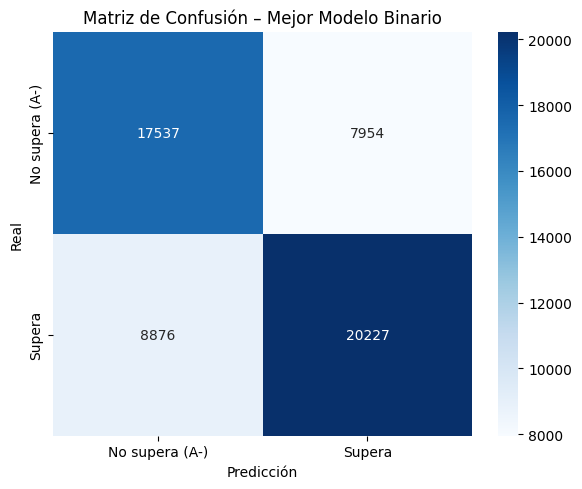

                precision    recall  f1-score   support

No supera (A-)       0.66      0.69      0.68     25491
        Supera       0.72      0.70      0.71     29103

      accuracy                           0.69     54594
     macro avg       0.69      0.69      0.69     54594
  weighted avg       0.69      0.69      0.69     54594


Criterio de selección:
  El modelo fue elegido por maximizar el F1-score,
  métrica que balancea precision y recall ante el desbalance de clases.
  El ROC-AUC complementa la evaluación indicando la capacidad
  discriminativa del modelo sobre todos los umbrales de probabilidad.


In [13]:
sep = '=' * 65
print(sep)
print('CONCLUSIÓN DEL EXPERIMENTO BINARIO')
print(sep)
mod, rn = mejor['modelo'], mejor['run_name']
acc_v, pr_v = mejor['accuracy'], mejor['precision']
rc_v,  f1_v = mejor['recall'],   mejor['f1_score']
au_v         = mejor['roc_auc']
print(f'Mejor modelo:  {mod}')
print(f'Run name:      {rn}')
print(f'Accuracy:      {acc_v:.4f}')
print(f'Precision:     {pr_v:.4f}')
print(f'Recall:        {rc_v:.4f}')
print(f'F1-score:      {f1_v:.4f}')
print(f'ROC-AUC:       {au_v:.4f}')
print()

if es_nn:
    y_prob_fin = best_nn_model.predict(X_test_proc, verbose=0).ravel()
    y_pred_fin = (y_prob_fin >= 0.5).astype(int)
else:
    y_pred_fin = best_xgb_model.predict(X_test_proc)

cm_fin = confusion_matrix(y_test, y_pred_fin)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_fin, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No supera (A-)', 'Supera'],
            yticklabels=['No supera (A-)', 'Supera'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión – Mejor Modelo Binario')
plt.tight_layout()
plt.savefig('confusion_matrix_binario_final.png', dpi=150)
plt.show()

print(classification_report(
    y_test, y_pred_fin, target_names=['No supera (A-)', 'Supera']))

print()
print('Criterio de selección:')
print('  El modelo fue elegido por maximizar el F1-score,')
print('  métrica que balancea precision y recall ante el desbalance de clases.')
print('  El ROC-AUC complementa la evaluación indicando la capacidad')
print('  discriminativa del modelo sobre todos los umbrales de probabilidad.')